In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cvsim.mechanisms import E_rev, E_q, E_qC, EE, SquareScheme
from cvsim.fit_curve import FitE_rev, FitE_q, FitE_qC, FitEE, FitSquareScheme

Text(0, 0.5, 'Current (mA)')

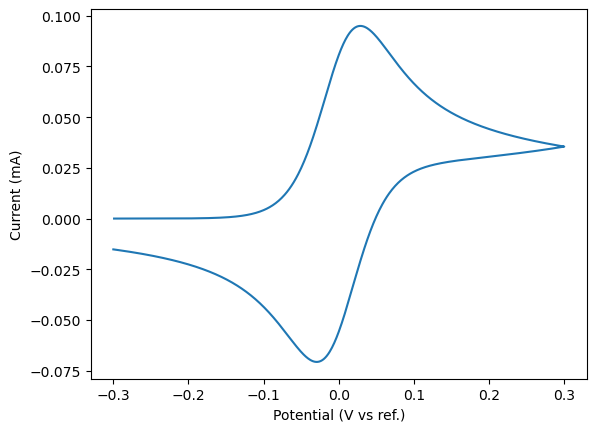

In [2]:
#Example: Reversible, one-electron mechanism
potential, current = E_rev(   # E_rev reversible
    start_potential=-0.3,     # V vs ref.
    switch_potential=0.3,     # V vs ref.
    reduction_potential=0.,   # V vs ref.
    scan_rate=0.1,            # V/s
    c_bulk=5,                 # mM
    diffusion_reactant=1e-5,  # cm2/s
    diffusion_product=1e-5,   # cm2/s
).simulate()
fig, ax = plt.subplots()
ax.plot(potential, current*1000)
ax.set_xlabel('Potential (V vs ref.)')
ax.set_ylabel('Current (mA)')

In [3]:
print("potential:", potential)
print("current:", current)

potential: [-0.299 -0.298 -0.297 ... -0.298 -0.299 -0.3  ]
current: [ 9.46389007e-09  9.83969288e-09  5.31057190e-09 ... -1.52876829e-05
 -1.52367460e-05 -1.51861281e-05]


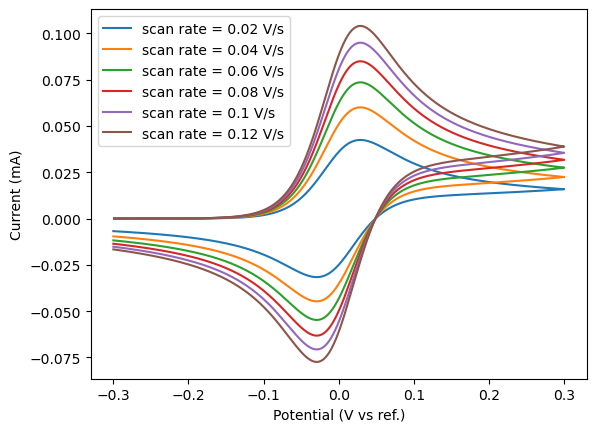

In [4]:
# CVs at different scan rates
scanV = [0.02, 0.04, 0.06, 0.08, 0.1, 0.12]
potential = [[] for i in range(len(scanV))]
current = [[] for i in range(len(scanV))]
for i in range(len(scanV)):
    potential[i], current[i] = E_rev(
        start_potential=-0.3,     # V vs ref.
        switch_potential=0.3,     # V vs ref.
        reduction_potential=0.0,  # V vs ref.
        scan_rate= float(scanV[i]),            # V/s
        c_bulk=5,                 # mM
        diffusion_reactant=1e-5,  # cm2/s
        diffusion_product=1e-5,   # cm2/s
    ).simulate()

fig, ax = plt.subplots()
for i in range(len(scanV)):
    ax.plot(potential[i], current[i]*1000, label="scan rate = "+str(scanV[i])+" V/s")
ax.set_xlabel('Potential (V vs ref.)')
ax.set_ylabel('Current (mA)')
ax.legend()

Text(0, 0.5, 'Current (mA)')

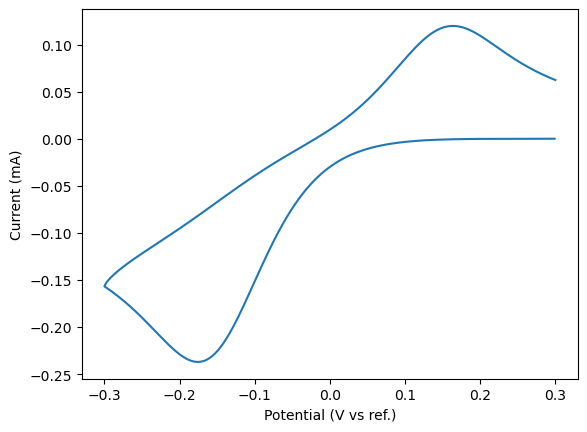

In [5]:
# Example: Quasi-reversible, one-electron mechanism
potential, current = E_q(     # E_q irreversibls
    start_potential=0.3,      # V vs ref.
    switch_potential=-0.3,    # V vs ref.
    reduction_potential=0.0,  # V vs ref.
    scan_rate=1,              # V/s
    c_bulk=5,                 # mM
    diffusion_reactant=1e-5,  # cm2/s
    diffusion_product=1e-5,   # cm2/s
    alpha=0.5,                # unitless
    k0=1e-3,                  # cm/s (rate constant at E0, 電子轉移速率)
).simulate()

fig,ax = plt.subplots()
ax.plot(potential, current*1000)
ax.set_xlabel('Potential (V vs ref.)')
ax.set_ylabel('Current (mA)')

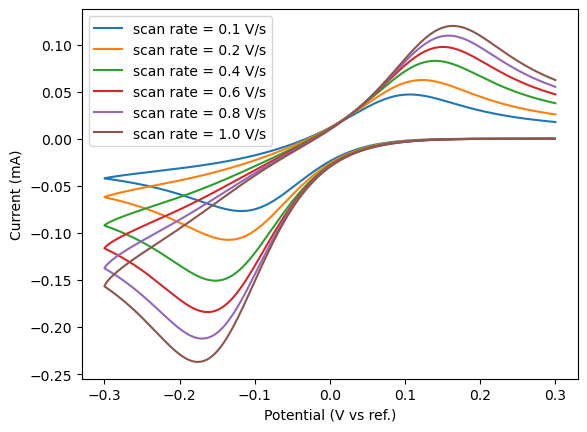

In [6]:
# CVs at different scan rates
scanV = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
potential = [[] for i in range(len(scanV))]
current = [[] for i in range(len(scanV))]
for i in range(len(scanV)):
    potential[i], current[i] = E_q(
        start_potential=0.3,      # V vs ref.
        switch_potential=-0.3,    # V vs ref.
        reduction_potential=0.0,  # V vs ref.
        scan_rate=float(scanV[i]),              # V/s
        c_bulk=5,                 # mM
        diffusion_reactant=1e-5,  # cm2/s
        diffusion_product=1e-5,   # cm2/s
        alpha=0.5,                # unitless
        k0=1e-3,                  # cm/s
    ).simulate()

fig, ax = plt.subplots()
for i in range(len(scanV)):
    ax.plot(potential[i], current[i]*1000, label="scan rate = "+str(scanV[i])+" V/s")
ax.set_xlabel('Potential (V vs ref.)')
ax.set_ylabel('Current (mA)')
ax.legend()

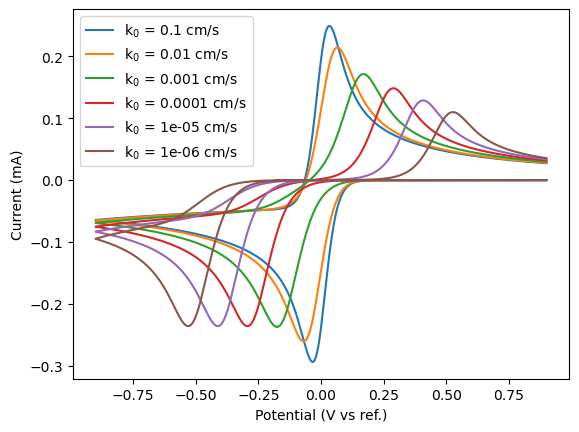

In [7]:
# CVs at different electron transfer rates
k0_list = [0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001]
potential = [[] for i in range(len(scanV))]
current = [[] for i in range(len(scanV))]
for i in range(len(k0_list)):
    potential[i], current[i] = E_q(
        start_potential=0.9,      # V vs ref.
        switch_potential=-0.9,    # V vs ref.
        reduction_potential=0.0,  # V vs ref.
        scan_rate=1.,              # V/s
        c_bulk=5,                 # mM
        diffusion_reactant=1e-5,  # cm2/s
        diffusion_product=1e-5,   # cm2/s
        alpha=0.5,                # unitless
        k0=float(k0_list[i]),                  # cm/s
    ).simulate()

fig, ax = plt.subplots()
for i in range(len(k0_list)):
    ax.plot(potential[i], current[i]*1000, label="k$_0$ = "+str(k0_list[i])+" cm/s")
ax.set_xlabel('Potential (V vs ref.)')
ax.set_ylabel('Current (mA)')
ax.legend()

Text(0, 0.5, 'Current (mA)')

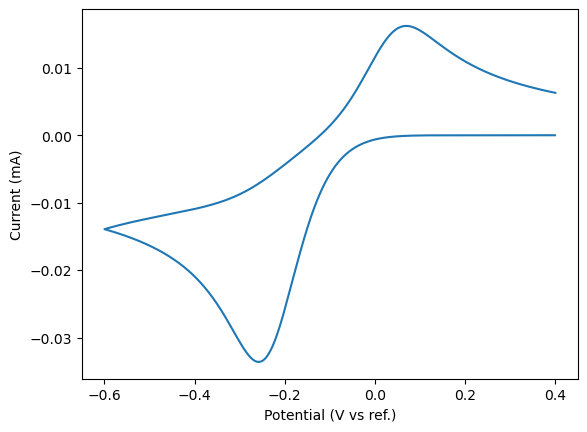

In [8]:
# Example: The EC mechanism
potential, current = E_qC(
    start_potential=0.4,       # V vs ref.
    switch_potential=-0.6,     # V vs ref.
    reduction_potential=-0.1,  # V vs ref.
    scan_rate=0.5,             # V/s
    c_bulk=1,                  # mM
    diffusion_reactant=1e-5,   # cm2/s
    diffusion_product=1e-5,    # cm2/s
    alpha=0.5,                 # unitless
    k0=1e-3,                   # cm/s
    k_forward=0.01,            # 1/s
    k_backward=0.015,          # 1/s
).simulate()

fig,ax = plt.subplots()
ax.plot(potential, current*1000)
ax.set_xlabel('Potential (V vs ref.)')
ax.set_ylabel('Current (mA)')

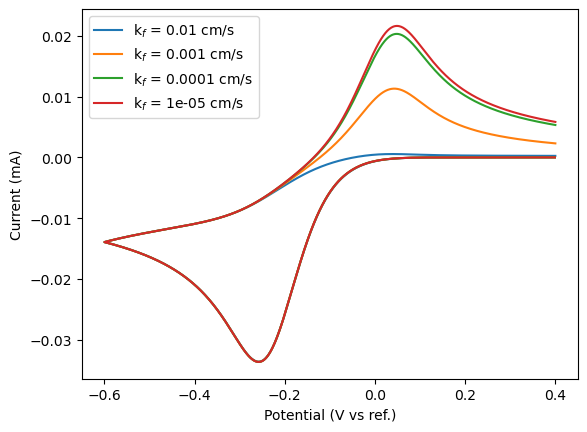

In [9]:
# Example: The EC mechanism at varying chemical kinetics
kf = [1e-2, 1e-3, 1e-4, 1e-5]
potential = [[] for i in range(len(kf))]
current = [[] for i in range(len(kf))]
for i in range(len(kf)):
    potential[i], current[i] = E_qC(
        start_potential=0.4,       # V vs ref.
        switch_potential=-0.6,     # V vs ref.
        reduction_potential=-0.1,  # V vs ref.
        scan_rate=0.5,             # V/s
        c_bulk=1,                  # mM
        diffusion_reactant=1e-5,   # cm2/s
        diffusion_product=1e-5,    # cm2/s
        alpha=0.5,                 # unitless
        k0=1e-3,                   # cm/s
        k_forward=float(kf[i]),            # 1/s
        k_backward=0.0001,          # 1/s
    ).simulate()

fig,ax = plt.subplots()
for i in range(len(kf)):
    ax.plot(potential[i], current[i]*1000, label="k$_f$ = "+str(kf[i])+" cm/s")
ax.set_xlabel('Potential (V vs ref.)')
ax.set_ylabel('Current (mA)')
ax.legend()


Text(0, 0.5, 'Current (mA)')

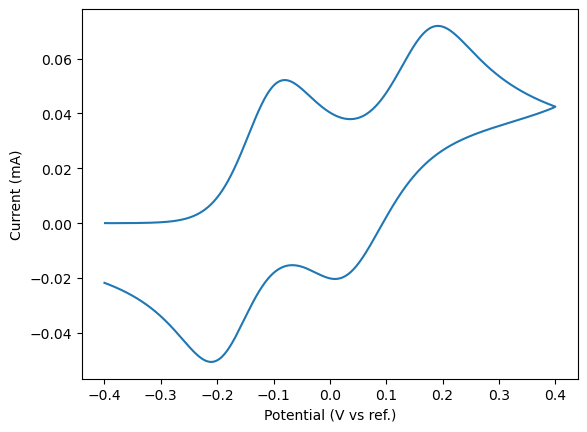

In [10]:
# Example: The EE mechanism
potential, current = EE(
    start_potential=-0.4,         # V vs ref.
    switch_potential=0.4,         # V vs ref.
    reduction_potential=-0.15,    # V vs ref.
    reduction_potential2=0.1,     # V vs ref.
    scan_rate=1.0,                # V/s
    c_bulk=1,                     # mM
    diffusion_reactant=1e-5,      # cm2/s
    diffusion_intermediate=1e-5,  # cm2/s
    diffusion_product=1e-5,       # cm2/s
    alpha=0.5,                    # unitless
    alpha2=0.5,                   # unitless
    k0=1e-2,                      # cm/s
    k0_2=5e-3,                    # cm/s
).simulate()

fig,ax = plt.subplots()
ax.plot(potential, current*1000)
ax.set_xlabel('Potential (V vs ref.)')
ax.set_ylabel('Current (mA)')

Text(0, 0.5, 'Current (mA)')

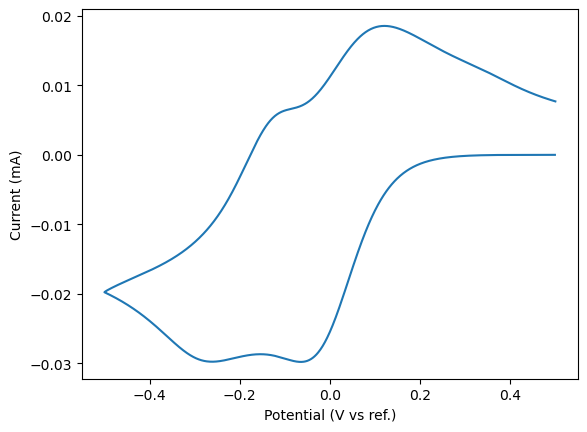

In [11]:
# Example: The Square Scheme mechanism
potential, current = SquareScheme(
    start_potential=0.5,        # V vs ref.
    switch_potential=-0.5,      # V vs ref.
    reduction_potential=0.2,    # V vs ref.
    reduction_potential2=-0.2,  # V vs ref.
    scan_rate=1.0,              # V/s
    c_bulk=1,                   # mM
    diffusion_reactant=1e-5,    # cm2/s
    diffusion_product=1e-5,     # cm2/s
    alpha=0.5,                  # unitless
    alpha2=0.5,                 # unitless
    k0=1e-3,                    # cm/s
    k0_2=5e-3,                  # cm/s
    k_forward=0.3,              # 1/s
    k_backward=0.1,             # 1/s
    k_forward2=0.01,            # 1/s
    k_backward2=0.002,          # 1/s
).simulate()

fig,ax = plt.subplots()
ax.plot(potential, current*1000)
ax.set_xlabel('Potential (V vs ref.)')
ax.set_ylabel('Current (mA)')